# Land Type Classification using Sentinel-2 Satellite Images
### **ResNet Edition** (Bayesian Optimization)
***

#### Imports:

In [1]:
#!pip install opencv-python seaborn matplotlib numpy pandas tensorflow scikit-learn scikit-optimize

In [2]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.python.platform.build_info import build_info
from tensorflow.config.experimental import list_physical_devices, VirtualDeviceConfiguration, set_virtual_device_configuration #type:ignore

from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.optimizers import Adam, RMSprop, SGD #type:ignore
from tensorflow.keras.models import Sequential, load_model #type:ignore
from tensorflow.keras.applications import ResNet50  #type:ignore
from tensorflow.keras.applications.resnet50 import preprocess_input #type:ignore
from tensorflow.keras.losses import CategoricalCrossentropy # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #type:ignore
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D #type:ignore
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

from pathlib import Path
import os
import shutil
import random
import csv

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

import pickle

#### Parameters (search `space`) and Settings:

In [3]:
space = [
    Categorical([128, 256, 512], name="dense_units"),
    Real(0.3, 0.7, name="dropout"),
    Categorical(["adam", "rmsprop", "sgd"], name="optimizer"),
    Real(1e-4, 5e-3, name="lr"),
    Categorical(["conv5_block1_out", "conv5_block2_out", "conv5_block3_out"], name="unfreeze_from"),
    Integer(1, 42, name="random_state")
]
image_size = (96,96)

***
### GPU Setup `tensorflow`
 1. Check if GPU register
 2. limiting VRAM (CUDA will allocate whole VRAM by Default)

In [4]:
print(tf.__version__)

GPU_RUN: bool = False

if list_physical_devices('GPU') != []:
    GPU_RUN = True
            
def limit_gpu_vram(vram = None):
    if vram == None:
        print("[!] Maximum GPU memory allowed")
        return
    
    gpus = list_physical_devices('GPU')
    try:
        set_virtual_device_configuration( gpus[0], [VirtualDeviceConfiguration(memory_limit= vram * 1024)] )
        print(f"[/] Limited GPU memory to {vram} GB.")
    except RuntimeError as e:
        print(e)

if GPU_RUN:
    print(tf.config.list_physical_devices('GPU'))

    print("-"*19)

    print("CUDA:", build_info["cuda_version"]) #type:ignore
    print("cuDNN:", build_info["cudnn_version"]) #type:ignore

    print("-"*19)
    
    limit_gpu_vram()

2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
-------------------
CUDA: 64_112
cuDNN: 64_8
-------------------
[!] Maximum GPU memory allowed


***
### Had to re-define `CategoricalFocalLoss` as it was missing in this old version of tensorflow
 - should have the same functionanlity

In [5]:
from tensorflow.keras.losses import Loss #type:ignore
from tensorflow.keras import backend as K #type:ignore

categorical_focal = None
if GPU_RUN:
    print("[!] Using custom GPU focal loss")
    class CategoricalFocalLoss(Loss):
        def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"): #type:ignore
            super().__init__(reduction=reduction, name=name)
            self.gamma = float(gamma)
            self.alpha = float(alpha)
            self.from_logits = from_logits

        def call(self, y_true, y_pred):
            if self.from_logits:
                y_pred = tf.nn.softmax(y_pred, axis=-1)
            eps = K.epsilon()
            y_pred = K.clip(y_pred, eps, 1.0 - eps)

            cross_entropy = -y_true * K.log(y_pred)

            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_factor = K.pow(1.0 - p_t, self.gamma)
            
            loss = self.alpha * focal_factor * cross_entropy
            loss = K.sum(loss, axis=-1)
            return K.mean(loss)

        def get_config(self):
            return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}
        
    categorical_focal = CategoricalFocalLoss()
else:
    print("[!] Using built-in CPU focal loss")
    from tensorflow.keras.losses import CategoricalFocalCrossentropy #type:ignore
    categorical_focal = CategoricalFocalCrossentropy()
    
print(categorical_focal)

[!] Using custom GPU focal loss


#### Split data into folders

In [3]:
project_root = Path(os.getcwd()).parent.parent

dataset_root = project_root / "Dataset"
original_folder = dataset_root / "EuroSAT_RGB"
base_folder = dataset_root / "EuroSAT_RGB_split"
checkpoints_dir = project_root / "Model_Fine_Tuning" / "Bayesian_Optimization" / "Checkpoints"

results_file = project_root / "Model_Fine_Tuning" / "Bayesian_Optimization" / "resnet_bayesian_optimization_results.csv"


print("Project Root:       ",project_root)
print("Dataset Root:       ",dataset_root)
print("Original Root:      ",original_folder)
print("Base Folder:        ",base_folder)
print("Checkpoints Folder: ",checkpoints_dir)
print("Results file:       ",results_file)

Project Root:        c:\Users\S1NdBAD\Desktop\DEPI Final Project
Dataset Root:        c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset
Original Root:       c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB
Base Folder:         c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB_split
Checkpoints Folder:  c:\Users\S1NdBAD\Desktop\DEPI Final Project\Model_Fine_Tuning\Bayesian_Optimization\Checkpoints
Results file:        c:\Users\S1NdBAD\Desktop\DEPI Final Project\Model_Fine_Tuning\Bayesian_Optimization\resnet_bayesian_optimization_results.csv


In [7]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [8]:
#split_data()


In [9]:
def cleanup_old_models(keep_top_n=3):
    ext = '.h5' if GPU_RUN else '.keras'
    df = pd.read_csv(results_file)
    top_trials = set(df.nlargest(keep_top_n, 'weighted_score')['trial'].values)
    
    for f in os.listdir(checkpoints_dir):
        if f.startswith('resnet50_') and f.endswith(ext):
            trial_num = int(f.split('_')[-1].replace(ext, ''))
            if trial_num not in top_trials:
                path = checkpoints_dir / f
                os.remove(path)
                print(f"[!] Efficient Clean: Deleted {f}")


#### split_data() Output:
 - AnnualCrop: 3000 images split into train/val/test
 - Forest: 3000 images split into train/val/test
 - HerbaceousVegetation: 3000 images split into train/val/test
 - Highway: 2500 images split into train/val/test
 - Industrial: 2500 images split into train/val/test
 - Pasture: 2000 images split into train/val/test
 - PermanentCrop: 2500 images split into train/val/test
 - Residential: 3000 images split into train/val/test 
 - River: 2500 images split into train/val/test 
 - SeaLake: 3000 images split into train/val/test


***
### **Objective Function for Bayesian Optimization**
 - Defining **Compile** and **Model structure** (Actuall run is in pre-last cell)
 - This function defines the **objective** used by the Bayesian optimizer (`gp_minimize`) to evaluate different CNN hyperparameter combinations.  
It builds, trains, and validates a Convolutional Neural Network (CNN)


In [10]:
@use_named_args(space)
def objective(**params):
    K.clear_session()
    # setting seeds
    rs = int(params["random_state"])
    random.seed(rs)
    np.random.seed(rs)
    tf.random.set_seed(rs)
    
    # Augmentation
    train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, rotation_range=20, fill_mode='nearest')
    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    
    # importing train, val, test data
    train_generator = train_datagen.flow_from_directory(base_folder / "train", target_size=image_size, batch_size=32, class_mode='categorical', shuffle=True)
    val_generator = val_test_datagen.flow_from_directory(base_folder / "validate", target_size=image_size, batch_size=32, class_mode='categorical', shuffle=False)
    test_generator = val_test_datagen.flow_from_directory(base_folder / "test", target_size=image_size, batch_size=32, class_mode='categorical', shuffle=False)
    
    tf.config.run_functions_eagerly(True)
    print(f"\nRunning with params: {params}")
    ### Phase I
    # base model definition
    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(*image_size, 3)
    )
    
    base_model.trainable = False
    # model definitoin
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(params['dense_units'], activation='relu'),
        BatchNormalization(),
        Dropout(params['dropout']),
        Dense(train_generator.num_classes, activation='softmax')
    ])

    if params['optimizer'] == 'adam':
        opt = Adam(learning_rate=params['lr'])
    elif params['optimizer'] == 'rmsprop':
        opt = RMSprop(learning_rate=params['lr'])
    else:
        opt = SGD(learning_rate=params['lr'], momentum=0.9)

    df = pd.read_csv(results_file)
    trial_num = df['trial'].max() + 1 if len(df) > 0 else 1
            
    modelcheckpoint = ModelCheckpoint(str(checkpoints_dir / f'resnet50_bayesian_{trial_num}.h5'), monitor='val_loss', save_best_only=True, verbose=0)
    if not GPU_RUN:
        modelcheckpoint = ModelCheckpoint(str(checkpoints_dir / f'resnet50_bayesian_{trial_num}.keras'), monitor='val_loss', save_best_only=True, verbose=0)
    # Phase 1: model compile
    model.compile(
        optimizer=Adam(learning_rate=params["lr"]),
        loss=categorical_focal,
        metrics=['accuracy']
    )

    callbacks = [
        modelcheckpoint,
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ]

    # Phase 1: model training
    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=20,
        callbacks=callbacks,
        verbose=0
    )

    ### Phase II
    # unfreeze all except last N layers
    unfreeze_from_layer_name = params["unfreeze_from"]
    unfreeze_from_index = next(
        i for i, l in enumerate(base_model.layers) if l.name == unfreeze_from_layer_name
    )

    # 1) Freeze ALL layers first
    for layer in base_model.layers:
        layer.trainable = False

    # 2) Unfreeze ONLY layers from selected layer onward
    for layer in base_model.layers[unfreeze_from_index:]:
        layer.trainable = True

    # Phase 2: model compile 
    model.compile(
        optimizer=opt,
        loss=categorical_focal,
        metrics=['accuracy']
    )
    # Phase 2: model training
    model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=20,
        callbacks=callbacks,
        verbose=0
    )
    
    if not GPU_RUN:
        temp_loaded_best = load_model(checkpoints_dir / f'resnet50_bayesian_{trial_num}.keras', compile=True)
        try:
            with open(checkpoints_dir / f'resnet50_bayesian_{trial_num}.pkl', 'wb') as f:
                pickle.dump(temp_loaded_best, f)
            print("[/] Model saved as pickle")
        except Exception as e:
            print(f"[x] Pickle save failed: {e}")
        
    # Evaluation
    preds = model.predict(test_generator, verbose=0)
    y_true = test_generator.classes
    y_pred = np.argmax(preds, axis=1)

    acc = np.mean(y_true == y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    weighted_score = acc * precision * recall * f1

    # saving results
    with open(results_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([trial_num, params['dense_units'], params['dropout'], params['optimizer'],
                         params['lr'], params['unfreeze_from'], params['random_state'],
                         round(acc,6), round(precision,6), round(recall,6), round(f1,6), round(weighted_score,6)]) #type:ignore
    
    print(f"Trial {trial_num}: acc={acc:.4f}, f1={f1:.4f}, weighted={weighted_score:.6f}")
    cleanup_old_models(keep_top_n=5)
    return -weighted_score


#### print used VRAM:

In [11]:
if GPU_RUN:
    gpus = tf.config.list_physical_devices('GPU')
    details = tf.config.experimental.get_memory_info(gpus[0].name[17:])
    
    print(f"[/] GPU: {gpus[0].name}")
    print(f"  Used VRAM: {details['current'] / 1024**2:.2f} MB")
    print(f"  Peak VRAM: {details['peak'] / 1024**2:.2f} MB")
else:
    print("[!] No GPU used")

[/] GPU: /physical_device:GPU:0
  Used VRAM: 0.00 MB
  Peak VRAM: 0.00 MB


***
#### **Load old results**

In [15]:
if not os.path.exists(results_file):
    os.makedirs(os.path.dirname(results_file), exist_ok=True)
    with open(results_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'trial', 'dense_units', 'dropout', 'optimizer', 'lr',
            'unfreeze_from', 'random_state', 'accuracy', 'precision',
            'recall', 'f1_score', 'weighted_score'
        ])

df = pd.read_csv(results_file)
print(f"Loaded {len(df)} past runs from {results_file.name}")
X_old = df[['dense_units', 'dropout', 'optimizer', 'lr', 'unfreeze_from', 'random_state']].values.tolist()
y_old = [-v for v in df['weighted_score'].values.tolist()]
if len(df) == 0:
    X_old, y_old = None, None;

Loaded 12 past runs from resnet_bayesian_optimization_results.csv


***
### **Start Bayesian Optimization**

In [ ]:
search_result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=15,
    x0=X_old,
    y0=y_old,
    random_state=42,
    verbose=True
)

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0010
Function value obtained: -0.8108
Current minimum: -0.8217
Iteration No: 2 started. Evaluating function at random point.
Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.

Running with params: {'dense_units': 512, 'dropout': 0.3733739159464655, 'optimizer': 'sgd', 'lr': 0.0030245657739377866, 'unfreeze_from': 'conv5_block2_out', 'random_state': 5}


c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Trial 13: acc=0.9449, f1=0.9449, weighted=0.797211
[!] Efficient Clean: Deleted resnet50_bayesian_13.h5
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 2190.5989
Function value obtained: -0.7972
Current minimum: -0.8217
Iteration No: 3 started. Evaluating function at random point.
Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.

Running with params: {'dense_units': 256, 'dropout': 0.4334834444556087, 'optimizer': 'adam', 'lr': 0.0032893535174493794, 'unfreeze_from': 'conv5_block1_out', 'random_state': 31}


c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Trial 14: acc=0.9427, f1=0.9426, weighted=0.789858
[!] Efficient Clean: Deleted resnet50_bayesian_14.h5
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 3912.8003
Function value obtained: -0.7899
Current minimum: -0.8217
Iteration No: 4 started. Evaluating function at random point.
Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.

Running with params: {'dense_units': 512, 'dropout': 0.30031150633640574, 'optimizer': 'sgd', 'lr': 0.003125659397175811, 'unfreeze_from': 'conv5_block2_out', 'random_state': 1}


c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Trial 15: acc=0.9402, f1=0.9402, weighted=0.781787
[!] Efficient Clean: Deleted resnet50_bayesian_15.h5
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 3343.2748
Function value obtained: -0.7818
Current minimum: -0.8217
Iteration No: 5 started. Evaluating function at random point.
Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.

Running with params: {'dense_units': 128, 'dropout': 0.5099098641033557, 'optimizer': 'rmsprop', 'lr': 0.0003286617497467156, 'unfreeze_from': 'conv5_block3_out', 'random_state': 11}


c:\Users\S1NdBAD\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\data\ops\structured_function.py:264: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


In [ ]:
print("\nBest Parameters Found:")
print(search_result.x) #type:ignore
print("Best Score:", -search_result.fun) #type:ignore

***
#### Read `VGG16_bayesian_optimization_results.csv` file

In [4]:
df = pd.read_csv(results_file)
df_sorted = df.sort_values(by="weighted_score", ascending=False)
df_sorted

,trial,dense_units,dropout,optimizer,lr,unfreeze_from,random_state,accuracy,precision,recall,f1_score,weighted_score
9,10,512,0.430616,rmsprop,0.002652,conv5_block3_out,36,0.952099,0.952143,0.952099,0.951982,0.821665
11,12,128,0.422913,sgd,0.000491,conv5_block3_out,13,0.948889,0.949018,0.948889,0.948834,0.810765
10,11,512,0.352789,adam,0.003903,conv5_block3_out,42,0.948148,0.948416,0.948148,0.947875,0.808169
3,4,128,0.509910,rmsprop,0.000329,conv5_block3_out,11,0.946667,0.947001,0.946667,0.946636,0.803393
7,8,128,0.456424,adam,0.003801,conv5_block2_out,10,0.945926,0.946310,0.945926,0.945931,0.800954
5,6,512,0.480200,adam,0.004717,conv5_block2_out,17,0.945926,0.946307,0.945926,0.945808,0.800847
1,2,256,0.433483,adam,0.003289,conv5_block1_out,31,0.945185,0.945907,0.945185,0.945219,0.798757
0,1,512,0.373374,sgd,0.003025,conv5_block2_out,5,0.944938,0.945230,0.944938,0.944880,0.797482
12,13,512,0.373374,sgd,0.003025,conv5_block2_out,5,0.944938,0.944930,0.944938,0.944859,0.797211
4,5,128,0.547354,rmsprop,0.004918,conv5_block2_out,36,0.944691,0.944688,0.944691,0.944588,0.796362


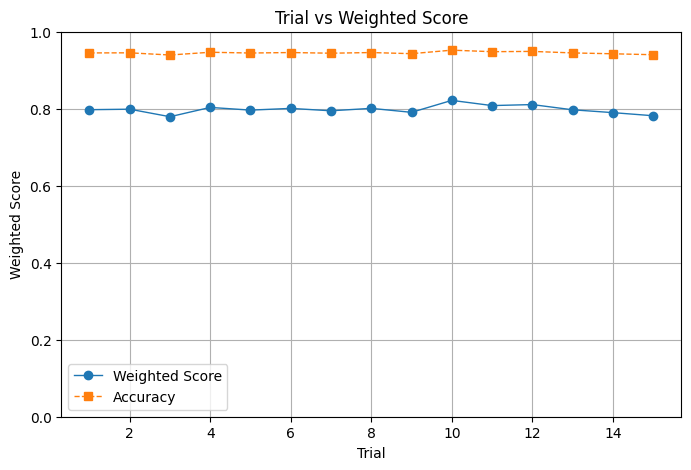

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(df["trial"], df["weighted_score"], marker='o', linestyle='-', linewidth=1, label='Weighted Score')
plt.plot(df["trial"], df["accuracy"], marker='s', linestyle='--', linewidth=1, label='Accuracy')
plt.legend()
plt.xlabel("Trial")
plt.ylabel("Weighted Score")
plt.ylim(0, 1)
plt.title("Trial vs Weighted Score")
plt.grid(True)